In [1]:
# proportion of each cell type in each niche

In [2]:
# %% Libraries
import os
import squidpy as sq
import scanpy as sc
#import scvi
import numpy as np
from pathlib import Path
import pandas as pd
#import novae
import matplotlib.pyplot as plt
import rapids_singlecell as rsc

import os
#import plotnine as p9

# %% Setting Paths
MAIN_DIR_NAME = "cosmx_cf_proseg"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
CUR_OBJ_V = 'cellcharter'
CUR_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{CUR_OBJ_V}.h5ad'

# %% Load the object
comb = sc.read_h5ad(CUR_OBJ_PATH)


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
comb

AnnData object with n_obs × n_vars = 1187341 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_

## Proportions table

In [5]:
# Run this entire block. Both plots use the same proportions table, with niche colours for the dots and cell-type colours for the bars.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ── Settings ──────────────────────────────────────────────────────────
CELLTYPE = "ann_lvl_3_refined"
NICHE = "cellcharter_niches"

MAX_DOT_AREA = 550
TOP_N = 5
N_COLS = 4

celltype_order = [
    "AT1", "AT2", "BC", "Club", "Gob", "MCC", "Deu", "Hillock",
    "AlvMac", "Mac", "Neut", "Mast", "B", "cB", "CD4_T", "CD8_T",
    "cLym", "PC_K_IgA", "PC_L_IgA", "PC_K_IgG", "PC_L_IgG",
    "PC_K_IgM", "PC_K_IgAG", "Fib", "actFib", "SMC", "EC",
    "lymEC", "Amb"
]

niche_order = [
    "Basal Airway", "Luminal Airway",
    "Alveolar Epithelium", "Alveolar Interstitium",
    "Stromal Interstitium", "BALT",
    "Plasma Rich", "Neutrophil Rich"
]


# ── Shared proportions table ──────────────────────────────────────────
obs = comb.obs[[CELLTYPE, NICHE]].dropna()
counts = pd.crosstab(obs[CELLTYPE], obs[NICHE])
counts = counts.loc[counts.sum(axis=1) > 0, counts.sum(axis=0) > 0]

if counts.empty:
    raise ValueError("No cells have both cell-type and niche annotations.")

missing = [c for c in celltype_order if c not in counts.index]
extra = [c for c in counts.index if c not in celltype_order]

if missing or extra:
    raise ValueError(
        f"Missing cell types: {missing}\n"
        f"Unexpected cell types: {extra}"
    )


def normalise(label):
    return str(label).replace("_", " ").strip().casefold()


def display_label(label):
    return str(label).replace("_", " ")


lookup = {normalise(n): n for n in counts.columns}

niches = [
    lookup[normalise(n)]
    for n in niche_order
    if normalise(n) in lookup
]
niches += [n for n in counts.columns if n not in niches]
celltypes = celltype_order

# Columns sum to 100%; pooled across all annotated cells in comb
proportions = (
    counts.div(counts.sum(axis=0), axis=1)
    .mul(100)
    .loc[celltypes, niches]
)


# ── Shared colour maps ────────────────────────────────────────────────
def saved_colour_map(key):
    labels = comb.obs[key]

    if not isinstance(labels.dtype, pd.CategoricalDtype):
        raise ValueError(
            f"comb.obs['{key}'] must be categorical "
            "to reliably match its saved colours."
        )

    colours = comb.uns[f"{key}_colors"]

    if len(colours) != len(labels.cat.categories):
        raise ValueError(f"Categories and saved colours differ for '{key}'.")

    return dict(zip(labels.cat.categories, colours))


celltype_colours = saved_colour_map(CELLTYPE)
niche_colours = saved_colour_map(NICHE)


def save_figure(fig, filename):
    for extension in ["pdf", "svg", "png"]:
        fig.savefig(
            f"{filename}.{extension}",
            dpi=300,
            bbox_inches="tight"
        )

## Dotplot coloured by niche

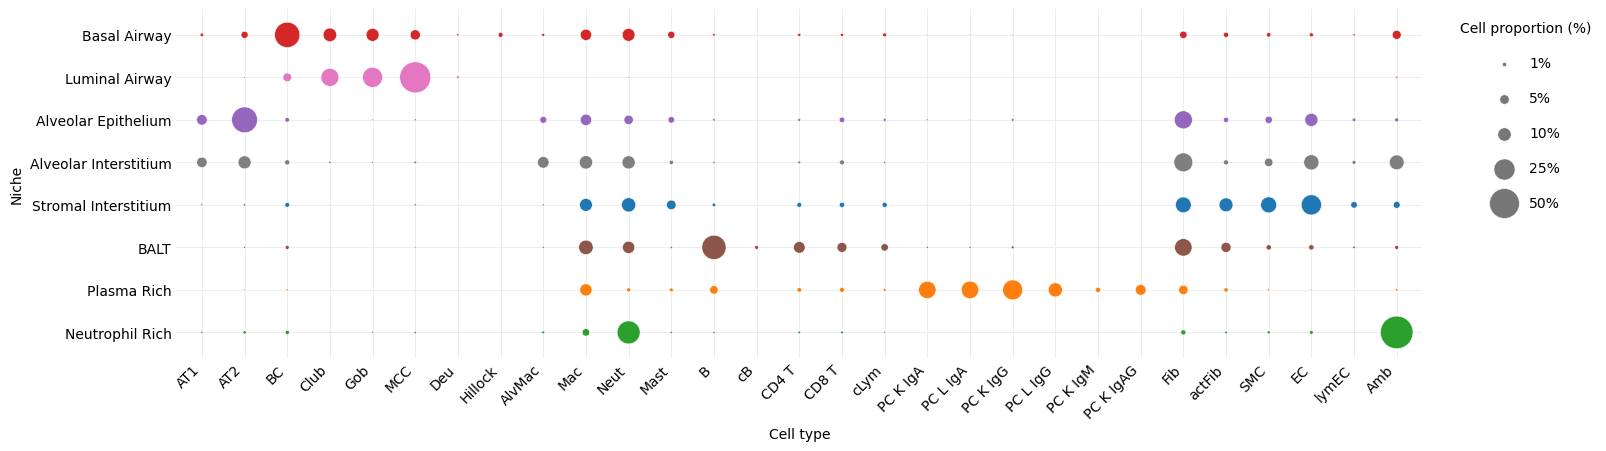

In [9]:
# ── Plot 1: dot plot, coloured by niche ────────────────────────────────
values = proportions.T.to_numpy()
max_pct = values.max()


def dot_area(pct):
    return np.asarray(pct) * MAX_DOT_AREA / max_pct


x, y = np.meshgrid(
    np.arange(len(celltypes)),
    np.arange(len(niches))
)

dot_colours = [
    niche_colours[niche]
    for niche in niches
    for _ in celltypes
]

fig_dot, ax = plt.subplots(
    figsize=(
        max(8, 0.55 * len(celltypes)),
        max(3, 0.55 * len(niches))
    ),
    constrained_layout=True
)

ax.scatter(
    x.ravel(),
    y.ravel(),
    s=dot_area(values.ravel()),
    c=dot_colours,
    edgecolors="white",
    linewidths=0.4,
    zorder=3
)

ax.set_xticks(
    np.arange(len(celltypes)),
    labels=[display_label(c) for c in celltypes],
    rotation=45,
    ha="right",
    fontsize=10
)
ax.set_yticks(
    np.arange(len(niches)),
    labels=[display_label(n) for n in niches],
    fontsize=10
)

ax.set(
    xlim=(-0.6, len(celltypes) - 0.4),
    ylim=(len(niches) - 0.4, -0.6),
    xlabel="Cell type",
    ylabel="Niche"
)

ax.set_axisbelow(True)
ax.grid(color="#EAEAEA", linewidth=0.6)
ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

legend_pcts = [
    p for p in [1, 5, 10, 25, 50, 75, 100]
    if p <= max_pct
]

handles = [
    ax.scatter(
        [], [],
        s=dot_area(p),
        color="#777777",
        edgecolors="white",
        linewidths=0.4,
        label=f"{p:g}%"
    )
    for p in (legend_pcts or [max_pct])
]

ax.legend(
    handles=handles,
    title="Cell proportion (%)",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    labelspacing=1.5
)

save_figure(fig_dot, "niche_celltype_dotplot")
plt.show()



## Multi Barplot

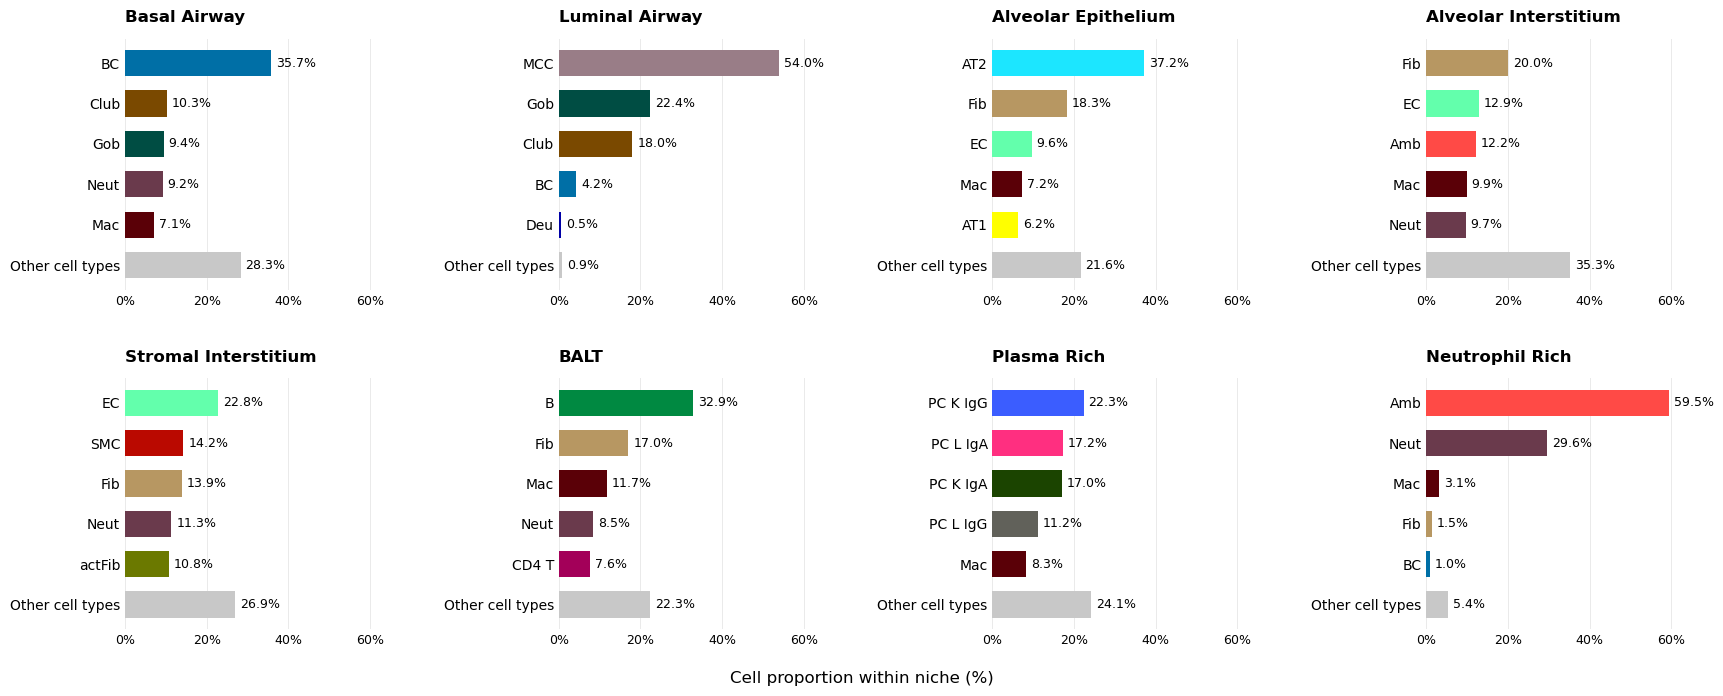

In [7]:

# ── Plot 2: top-five bars, coloured by cell type ───────────────────────
panels = {}

for niche in niches:
    pct = proportions[niche]
    pct = pct[pct > 0].sort_values(ascending=False, kind="stable")

    top = pct.iloc[:TOP_N]
    other = pct.iloc[TOP_N:].sum()

    labels = [display_label(c) for c in top.index]
    bar_values = top.tolist()
    bar_colours = [celltype_colours[c] for c in top.index]

    if other > 0:
        labels.append("Other cell types")
        bar_values.append(other)
        bar_colours.append("#C8C8C8")

    panels[niche] = (labels, bar_values, bar_colours)

# Common scale, with additional room for percentage labels
largest = max(max(v) for _, v, _ in panels.values())
tick_max = min(100, max(10, np.ceil(largest / 10) * 10))
axis_max = tick_max * 1.16
tick_step = 10 if tick_max <= 30 else 20

n_cols = min(N_COLS, len(niches))
n_rows = int(np.ceil(len(niches) / n_cols))

fig_bar, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.3 * n_cols, 3.5 * n_rows),
    sharex=True,
    squeeze=False,
    constrained_layout=True
)

fig_bar.set_constrained_layout_pads(
    w_pad=0.08,
    h_pad=0.12,
    wspace=0.08,
    hspace=0.12
)

for ax, niche in zip(axes.flat, niches):
    labels, bar_values, bar_colours = panels[niche]
    y = np.arange(len(labels))

    ax.barh(
        y,
        bar_values,
        height=0.65,
        color=bar_colours,
        edgecolor="none",
        zorder=3
    )

    ax.set_yticks(y, labels=labels, fontsize=10)
    ax.invert_yaxis()

    ax.set_title(
        display_label(niche),
        fontsize=12,
        fontweight="bold",
        loc="left",
        pad=12
    )

    for i, value in enumerate(bar_values):
        ax.text(
            value + tick_max * 0.02,
            i,
            f"{value:.1f}%",
            va="center",
            ha="left",
            fontsize=9
        )

    ax.set_xlim(0, axis_max)
    ax.set_xticks(np.arange(0, tick_max + 0.1, tick_step))
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.tick_params(axis="x", labelbottom=True, labelsize=9, length=0)
    ax.tick_params(axis="y", length=0)

    ax.set_axisbelow(True)
    ax.grid(axis="x", color="#EAEAEA", linewidth=0.7)

    for spine in ax.spines.values():
        spine.set_visible(False)

for ax in axes.flat[len(niches):]:
    ax.set_visible(False)

fig_bar.supxlabel("Cell proportion within niche (%)", fontsize=12)

save_figure(fig_bar, "niche_composition_top5")
plt.show()

## Horizontal barplot

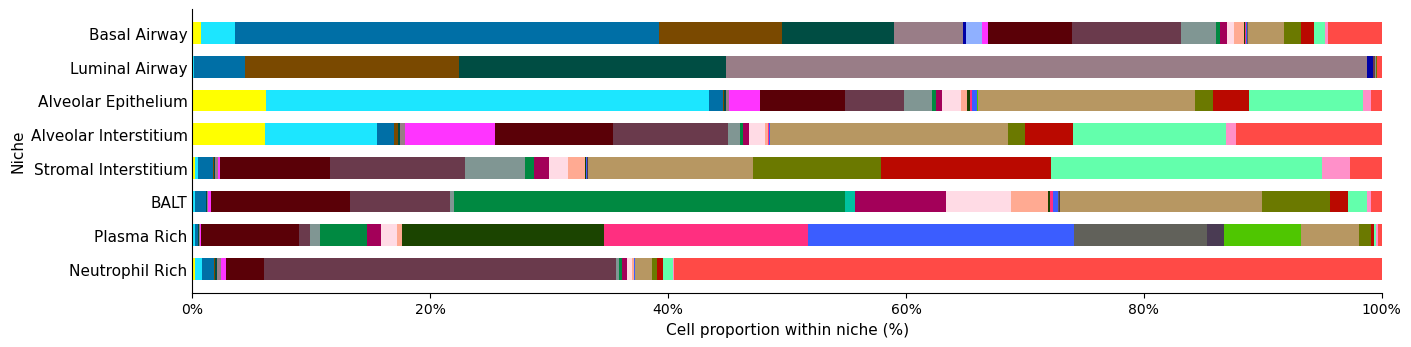

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Existing table: rows = cell types, columns = niches, values = percentages
plot_df = proportions.loc[celltypes, niches].T

fig, ax = plt.subplots(
    figsize=(14, max(3, 0.42 * len(plot_df))),
    constrained_layout=True
)

left = np.zeros(len(plot_df))

for celltype in plot_df.columns:
    values = plot_df[celltype].to_numpy()

    ax.barh(
        np.arange(len(plot_df)),
        values,
        left=left,
        height=0.65,
        color=celltype_colours[celltype],
        edgecolor="none",
        label=str(celltype).replace("_", " ")
    )

    left += values

ax.set_yticks(
    np.arange(len(plot_df)),
    labels=[str(n).replace("_", " ") for n in plot_df.index],
    fontsize=11
)
ax.invert_yaxis()

ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 101, 20))
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.set_xlabel("Cell proportion within niche (%)", fontsize=11)
ax.set_ylabel("Niche", fontsize=11)

ax.tick_params(axis="y", length=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# No legend, matching your reference.
# Uncomment to add a legend below:
# ax.legend(
#     loc="upper center",
#     bbox_to_anchor=(0.5, -0.22),
#     ncol=8,
#     frameon=False,
#     fontsize=9
# )

for extension in ["pdf", "svg", "png"]:
    fig.savefig(
        f"niche_composition_stacked.{extension}",
        dpi=300,
        bbox_inches="tight"
    )

plt.show()